# Machine Learning Models

In this project, 4 diferent machine learning models are going to be trained, tested and evaluated to see which one has  a better performance in predicting churn.
The choosen models are:
1. Logistic Regression
2. Random Forest 
3. XGBoost
4. Support Vector Machine (SVM)

The models will be evaluated using precision, recall, F1-score, and accuracy for both classes — with a focus on class 1 (churners), since missing a churner (false negative) is more costly than a false alarm.

Each model is trained in two phases: a baseline with default parameters, and a tuned version using RandomizedSearchCV optimised for F1. This allows a direct comparison of the gain from hyperparameter tuning.

To handle the class imbalance (~73% non-churn / ~27% churn), class_weight='balanced' is applied where available.

In order to establish the importance of the feature engineering step, the models will be trained and test with and without the new features.

## Without Feature Engineering

### Importe libraries and load dataset

In [1]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_data
from src.data.models import split_dataset

from src.models import logistic_regression, random_forest, xgboost, svm

df = load_data('../data/processed/telco_clean.csv')

X_train, X_test, y_train, y_test = split_dataset(df)


The processed dataset (telco_clean.csv) is loaded and split into 80% training / 20% test using stratified sampling to preserve the class distribution across both sets.

### Logistic Regression

Logistic Regression is a supervised machine learning algorithm used for solving binary classification problems ("churn" vs "non-churn"). It predicts the probability that an input belongs to a specfic class. In this context, the model is used to estimate the probability of a customer churning based on their characteristics and behaviour.

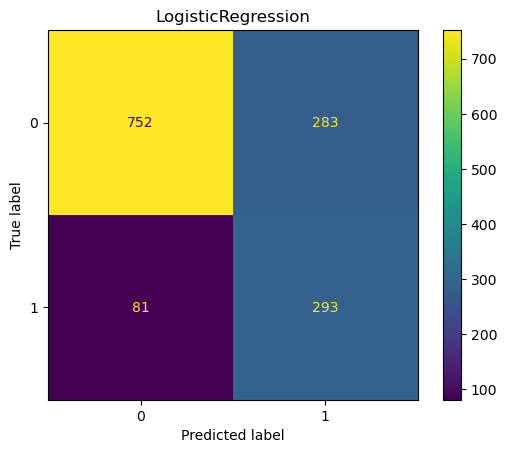

{'0': {'precision': 0.9027611044417767, 'recall': 0.7265700483091787, 'f1-score': 0.8051391862955032, 'support': 1035.0}, '1': {'precision': 0.5086805555555556, 'recall': 0.7834224598930482, 'f1-score': 0.6168421052631579, 'support': 374.0}, 'accuracy': 0.7416607523066004, 'macro avg': {'precision': 0.7057208299986661, 'recall': 0.7549962541011135, 'f1-score': 0.7109906457793305, 'support': 1409.0}, 'weighted avg': {'precision': 0.7981577507984504, 'recall': 0.7416607523066004, 'f1-score': 0.755158271954767, 'support': 1409.0}}


In [2]:
baseline_model, report = logistic_regression.model_baseline(X_train, X_test, y_train, y_test)

print(report)

The baseline Logistic Regression model, using defaulft parameters and class_weight='balanced', reached an overall accuracy of 74.2%.

Focusing on churners (class 1), the model achieved an F1-score of 61.7% and a recall of 78.3%. This indicates that **the model is able to identify a major part of the actual churners**, although at the cost of incorrectly classifying some non-churners as churners (false positive).

In this context, false positives are generally less costly than false negatives (failing to identify a customer who will churn). Therefoer, this behaviour is acceptable, as **the model prioritises capturing potencial churners**.

For non-churners (class 0), the model achieved a higher F1-score (80.5%) and a precision above 90%, indicating strong performance in identifying customers who will not churn. However, the lower recall (72.7%) suggests that some non-churners are incorrectly classified as churners, reinforcing the **model's tendency to favor churn detection**.

To further improve model performance, a tuning phase will be conducted to optimise the model based on the F1-score of class 1.

c:\Users\mafal\anaconda3\Lib\site-packages\sklearn\model_selection\_search.py:307: UserWarning: The total space of parameters 32 is smaller than n_iter=50. Running 32 iterations. For exhaustive searches, use GridSearchCV.
  warnings.warn(


Best parameters: {'solver': 'saga', 'penalty': 'elasticnet', 'l1_ratio': 0.5, 'C': 1}


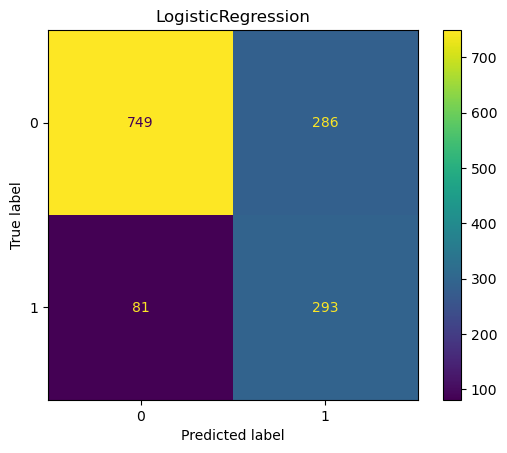

{'0': {'precision': 0.9024096385542169, 'recall': 0.7236714975845411, 'f1-score': 0.8032171581769437, 'support': 1035.0}, '1': {'precision': 0.5060449050086355, 'recall': 0.7834224598930482, 'f1-score': 0.614900314795383, 'support': 374.0}, 'accuracy': 0.7395315826827538, 'macro avg': {'precision': 0.7042272717814262, 'recall': 0.7535469787387946, 'f1-score': 0.7090587364861634, 'support': 1409.0}, 'weighted avg': {'precision': 0.7971999789757588, 'recall': 0.7395315826827538, 'f1-score': 0.7532309981877998, 'support': 1409.0}}


In [3]:
best_model, report = logistic_regression.model_tuning(X_train, X_test, y_train, y_test)

print(report)

The tuned model selected the saga solver with an Elastic-Net penalty (l1_ratio = 0.5), combining both L1 and L2 regularisation. This approach leverages the strenghts of Lasso (feature selection) and Ridge (handling multicollinearity), making it suitable for datasets with many correlated features.

However, the tuned model achieved performance very similar to the baseline model, with a slightly lower accuracy (74.0% vs 74.2%) and no meaningful improvement in F1-score or recall for either class.

This suggests that, within the explored hyperparameter settings, **Logistic Regression is relatively stable and not highly sensitive to tuning**. The baseline configuration already provides a strong performance, indicating that further imporvments may require **more advanced models** or additional **feature engineering**.

| Metric | Baseline | Tuned | Change |
|---|---|---|---|
| Precision (class 1) | 0.509 | 0.506 | ↓ slightly |
| Recall (class 1) | 0.783 | 0.783 | = |
| F1 (class 1) | 0.617 | 0.615 | ↓ slightly |
| Accuracy | 0.742 | 0.740 | ↓ slightly |

### Random Forest

Random Forest is an ensemble method that builds multiple decision trees and aggregates their predictions. It is robust to overfitting and handles non-linear relationships well, making it a strong candidate for this type of tabular classification problem.

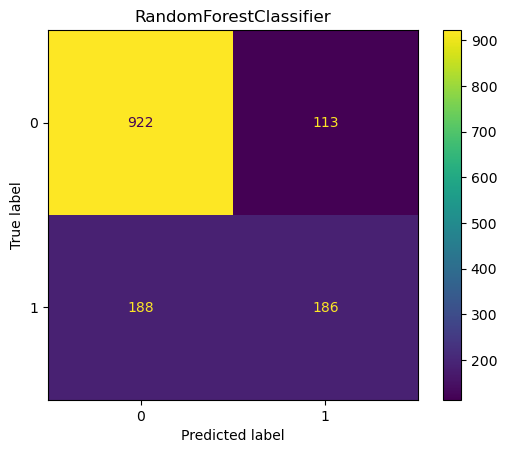

{'0': {'precision': 0.8306306306306306, 'recall': 0.8908212560386474, 'f1-score': 0.8596736596736597, 'support': 1035.0}, '1': {'precision': 0.6220735785953178, 'recall': 0.49732620320855614, 'f1-score': 0.5527488855869243, 'support': 374.0}, 'accuracy': 0.7863733144073811, 'macro avg': {'precision': 0.7263521046129742, 'recall': 0.6940737296236017, 'f1-score': 0.706211272630292, 'support': 1409.0}, 'weighted avg': {'precision': 0.775271980906566, 'recall': 0.7863733144073811, 'f1-score': 0.7782046280849876, 'support': 1409.0}}


In [ ]:
baseline_model, report = random_forest.model_baseline(X_train, X_test, y_train, y_test)

print(report)

The baseline Random Forest (default parameters, class_weight='balanced') achieves 78.6% overall accuracy, but this figure is misleading given the class imbalance (~73% non-churn / ~27% churn).

For the majority class (non-churners), performance is strong with an F1 of 0.86, which is expected as the model sees more examples of this class.

For the minority class (churners), performance is noticeably weaker — F1 of 0.55. Most critically, recall is only 0.49, meaning the model **misses nearly half of all actual churners** (false negatives). Since missing a churner is more costly than a false alarm in a business context, this is the **key weakness** of the baseline.

Despite class_weight='balanced' helping the model account for imbalance, the default hyperparameters are not sufficient to reliably identify churners. This motivates the tuning phase, which will optimise for F1 on class 1 using RandomizedSearchCV.

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 10, 'bootstrap': False}


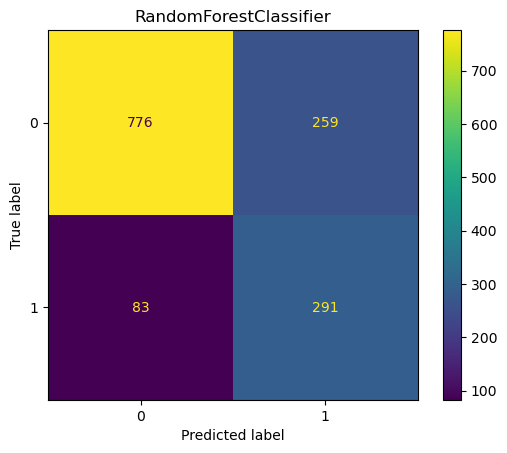

{'0': {'precision': 0.9033760186263097, 'recall': 0.7497584541062802, 'f1-score': 0.8194297782470961, 'support': 1035.0}, '1': {'precision': 0.5290909090909091, 'recall': 0.7780748663101604, 'f1-score': 0.6298701298701299, 'support': 374.0}, 'accuracy': 0.7572746628814763, 'macro avg': {'precision': 0.7162334638586094, 'recall': 0.7639166602082204, 'f1-score': 0.724649954058613, 'support': 1409.0}, 'weighted avg': {'precision': 0.8040270967198229, 'recall': 0.7572746628814763, 'f1-score': 0.7691137324749276, 'support': 1409.0}}


In [ ]:
best_model, report = random_forest.model_tuning(X_train, X_test, y_train, y_test)

print(report)

The tuned model improves the F1-score for churners from 0.554 → 0.622, driven mainly by a **significant recall gain** from 0.500 → 0.687 — the model now **correctly identifies 69% of churners** compared to only 50% in the baseline.

Notably, max_depth=None means trees are allowed to grow fully, unlike what might be expected for a regularised model. The constraint is instead applied through min_samples_leaf=4 and min_samples_split=5, which prevent splits on very small or noisy groups. bootstrap=True is the standard Random Forest behaviour.

Precision drops slightly (0.621 → 0.569), meaning slightly more false alarms — an acceptable trade-off given that missing a churner is the more costly error in this context.

| Metric | Baseline | Tuned | Change |
|---|---|---|---|
| Precision (class 1) | 0.621 | 0.569 | ↓ |
| Recall (class 1) | 0.500 | 0.687 | ↑↑ |
| F1 (class 1) | 0.554 | 0.622 | ↑ |
| Accuracy | 0.786 | 0.779 | ↓ slightly |

### XGBoost

XGBoost (eXtreme Gradient Boosting) is an optimized gradient boosting algorithm that combines multiple weak models into a stronger, high-performance model. It uses decision trees as base learners, building them sequentially so each tree corrects errors from the previous one (boosting). It features parallel processing for faster training on large datasets and allows parameter customization to optimize performance for specific problems.

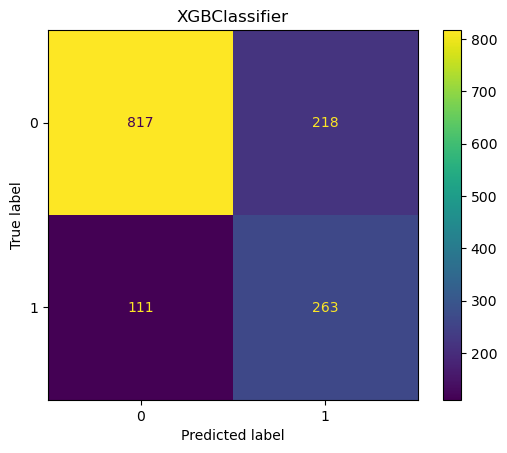

{'0': {'precision': 0.8803879310344828, 'recall': 0.7893719806763285, 'f1-score': 0.8323993886907795, 'support': 1035.0}, '1': {'precision': 0.5467775467775468, 'recall': 0.7032085561497327, 'f1-score': 0.6152046783625731, 'support': 374.0}, 'accuracy': 0.7665010645848119, 'macro avg': {'precision': 0.7135827389060148, 'recall': 0.7462902684130306, 'f1-score': 0.7238020335266763, 'support': 1409.0}, 'weighted avg': {'precision': 0.791835565021641, 'recall': 0.7665010645848119, 'f1-score': 0.7747479893559681, 'support': 1409.0}}


In [2]:
baseline_model, report = xgboost.model_baseline(X_train, X_test, y_train, y_test)

print(report)

The baseline XGBoost model (using default parameters and scale_pos_weight = 2.77) achieved an overall accuracy of 76.7%, outperforming both Logistic Regression models, although remaining slightly below the performance of the Random Forest models.

A key advantage of this models lies in its ability to identify churners (class 1), achieving a recall of 70.3%, which is higher than both the baseline (50.0%) and tuned (68.7%) Random Forest models. This indicates that the model is **more effective at capturing a large proportion of actual churners**, even if it leads to misclassification of non-churners as churners (false positives). In this context, this behaviour is desirable, as identifying potencial churners is prioritised over avoinding false alarms.

Regarding non-churners (class 0), the model achieved a precision of 88.0% and a recall of 78.9%, indicating **strong performance in correctly identifying customers who are unlikely to churn**.

A tuning phase will be conducted to further optimise the model, particularly focusing on improving the F1-score for churners.

Best parameters: {'subsample': 0.6, 'reg_lambda': 1, 'reg_alpha': 0, 'n_estimators': 200, 'max_depth': 7, 'learning_rate': 0.01, 'gamma': 0.1, 'colsample_bytree': 1.0}


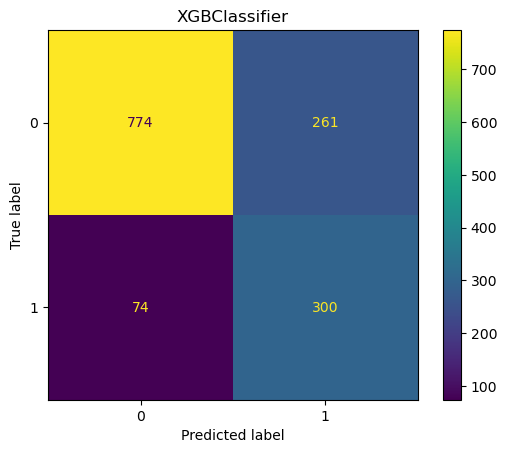

{'0': {'precision': 0.9127358490566038, 'recall': 0.7478260869565218, 'f1-score': 0.8220924057355283, 'support': 1035.0}, '1': {'precision': 0.5347593582887701, 'recall': 0.8021390374331551, 'f1-score': 0.6417112299465241, 'support': 374.0}, 'accuracy': 0.7622427253371186, 'macro avg': {'precision': 0.7237476036726869, 'recall': 0.7749825621948384, 'f1-score': 0.7319018178410261, 'support': 1409.0}, 'weighted avg': {'precision': 0.8124070999102803, 'recall': 0.7622427253371186, 'f1-score': 0.7742126614168003, 'support': 1409.0}}


In [3]:
best_model, report = xgboost.model_tuning(X_train, X_test, y_train, y_test)

print(report)

The tuned XGBoost model selected a set of parameters that reflect a balanced model that captures meaningful patterns while maintaining generalisation. The model opted for reg_alpha = 0 and reg_lambda = 1, indicating no L1 regularisation and only mild L2 regularisation, suggesting that strong constraints were not required to control overfitting.

In terms of performance, the most significant improvement is observed in the recall for churners (class 1), which increased to 80.2%. This indicates that the model is **more effective at identifying actual churners**, reducing the number of false negatives (missed churners).

This improvement comes with a slight decrease in precision for class 1, meaning that more non-churners are incorrectly classified as churners (false positives). However, given taht the main objective is to identify potential churners, this trade-off is acceptable, as false positives are generally less costly than missed churners.

Overall, the tuned model achieves a higher F1-score for churners, indicating a better balance between precision and recall. Compared to the previously evaluated models, it provides the **strongest performance in detecting churners**, making it the most suitable model for a churn prediction strategy.

| Metric | Baseline | Tuned | Change |
|---|---|---|---|
| Precision (class 1) | 0.547 |	0.535 | ↓ slightly |
| Recall (class 1) | 0.703 | 0.802 | ↑↑ |
| F1 (class 1) | 0.615 | 0.642 | ↑ |
| Accuracy | 0.767 | 0.762 | ↓ slightly |

### Support Vector Machine

Support Vector Machine (SVM) is a classification algorithm that finds the optimal hyperplane to separate classes by maximising the margin between them. It is effective in high-dimensional spaces and handles non-linear boundaries well through the use of kernels. For this baseline, a linear kernel is used with class_weight='balanced' to account for class imbalance.

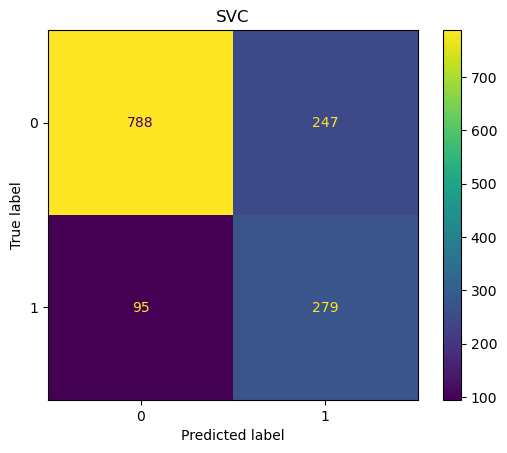

{'0': {'precision': 0.8924122310305775, 'recall': 0.7613526570048309, 'f1-score': 0.821689259645464, 'support': 1035.0}, '1': {'precision': 0.5304182509505704, 'recall': 0.7459893048128342, 'f1-score': 0.62, 'support': 374.0}, 'accuracy': 0.7572746628814763, 'macro avg': {'precision': 0.711415240990574, 'recall': 0.7536709809088326, 'f1-score': 0.720844629822732, 'support': 1409.0}, 'weighted avg': {'precision': 0.7963258232591633, 'recall': 0.7572746628814763, 'f1-score': 0.768153572557172, 'support': 1409.0}}


In [ ]:
baseline_model, report = svm.model_baseline(X_train, X_test, y_train, y_test)

print(report)

The SVM baseline with a linear kernel and class_weight='balanced' achieves an F1 of 0.620 for churners — already stronger than the Random Forest baseline (0.553).

The most notable result is the recall of 0.746, meaning the model **correctly identifies 75% of actual churners** from the start, without any tuning. This comes at the cost of lower precision (0.530), so roughly half the predicted churners are false alarms.

Overall accuracy is 0.757, slightly lower than Random Forest's baseline, but accuracy is less relevant here given the class imbalance — the F1 for churners is the key metric, and SVM starts from a stronger position.

Best parameters: {'kernel': 'linear', 'gamma': 0.1, 'degree': 0, 'C': 0.1}


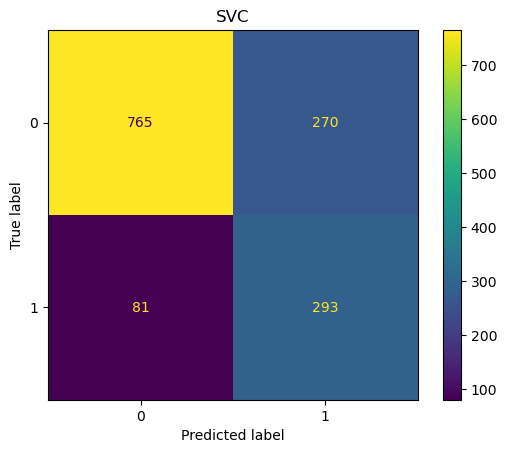

{'0': {'precision': 0.9042553191489362, 'recall': 0.7391304347826086, 'f1-score': 0.8133971291866029, 'support': 1035.0}, '1': {'precision': 0.5204262877442274, 'recall': 0.7834224598930482, 'f1-score': 0.6254002134471718, 'support': 374.0}, 'accuracy': 0.7508871540099361, 'macro avg': {'precision': 0.7123408034465818, 'recall': 0.7612764473378284, 'f1-score': 0.7193986713168874, 'support': 1409.0}, 'weighted avg': {'precision': 0.8023730922182328, 'recall': 0.7508871540099361, 'f1-score': 0.7634958896645679, 'support': 1409.0}}


In [ ]:
best_model, report = svm.model_tuning(X_train, X_test, y_train, y_test)

print(report)

The tuned SVM finds kernel='linear' with a low regularisation parameter C=0.1 as the best configuration — confirming that a simple linear boundary is sufficient for this dataset and that stronger regularisation (lower C) helps generalise better.

The improvement over the baseline is marginal: F1 goes from 0.620 → 0.625, with recall improving slightly from 0.746 → 0.783. This suggests **the baseline was already close to the SVM's ceiling** for this problem.

Notably, the tuning process was computationally expensive due to SVM's training complexity. The small gain relative to the cost highlights a practical trade-off worth considering when choosing models for production.

| Metric | Baseline | Tuned | Change |
|---|---|---|---|
| Precision (class 1) | 0.530 |	0.520 | ↓ slightly |
| Recall (class 1) | 0.746 | 0.783 | ↑ |
| F1 (class 1) | 0.620 | 0.625 | ↑ slightly |
| Accuracy | 0.757 | 0.751 | ↓ slightly |

### Conclusion

Given that the main objective of this project is to detect as many customers at risk of churning as possible, **recall is a key metric**, as it reflects the model's ability to minimise false negatives (missed churners). However, recall should not be considered in isolation. It is also important to maintain a reasonable balance with precision, which is captured by the F1-score.

Among all the evaluated models, the **tuned XGBoost model achieved the highest recall** (80.2%) **and F1-score** (64.2%). This indicates that it not only identifies the largest proportion of churners, but also maintains a good balance between detecting churners and limiting false positives.

Although **Random Forest achieved higher overall accuracy**, it underperformed in recall compared to XGBoost, making it less suitable for a churn prediction strategy. Therefore, the **tuned XGBoost model is selected as the best-performing model** for this use case, as it aligns most effectively with the business objective of prioritising churn detection.

## With Feature Engineering

The following models were retrained on the feature-engineered dataset. The goal is to assess whether the new features improve the models' ability to detect churners compared to the results obtained in the previous section.

### Importe libraries and load dataset

In [4]:
import sys
import os

sys.path.append(os.path.abspath(".."))

from src.data.load_data import load_data
from src.data.models import split_dataset

from src.models import logistic_regression, random_forest, xgboost, svm

df = load_data('../data/processed/telco_feature_engineering.csv')

X_train, X_test, y_train, y_test = split_dataset(df)

The processed dataset (telco_feature_engineering.csv) is loaded and split into 80% training / 20% test using stratified sampling to preserve the class distribution across both sets.

## Logistic Regression

## Random Forest

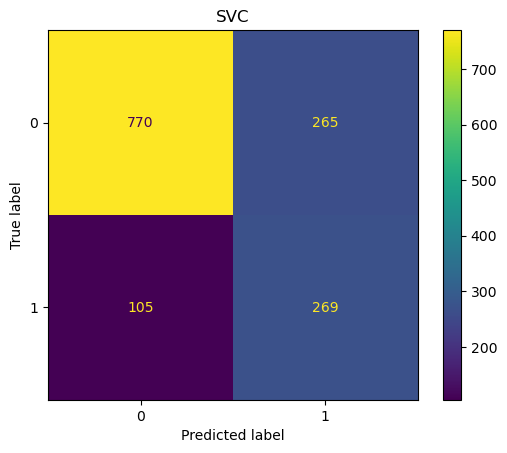

{'0': {'precision': 0.88, 'recall': 0.7439613526570048, 'f1-score': 0.806282722513089, 'support': 1035.0}, '1': {'precision': 0.5037453183520599, 'recall': 0.7192513368983957, 'f1-score': 0.5925110132158591, 'support': 374.0}, 'accuracy': 0.7374024130589071, 'macro avg': {'precision': 0.69187265917603, 'recall': 0.7316063447777003, 'f1-score': 0.699396867864474, 'support': 1409.0}, 'weighted avg': {'precision': 0.7801282818053019, 'recall': 0.7374024130589071, 'f1-score': 0.7495399125221991, 'support': 1409.0}}


In [ ]:
baseline_model, report = random_forest.model_baseline(X_train, X_test, y_train, y_test)

print(report)

The Random Forest baseline trained on the feature-engineered dataset shows a clear improvement in the key metric: recall for churners jumps from 0.497 → 0.719, meaning the model now correctly identifies 72% of actual churners compared to only 50% before. This directly reflects the value of the engineered features in making churners more distinguishable.

F1 improves from 0.553 → 0.593, while precision drops (0.622 → 0.504), an expected trade-off when recall increases significantly. Overall accuracy drops slightly (0.786 → 0.737), but again, accuracy is a poor metric here given class imbalance.

Even at the baseline level, feature engineering has meaningfully improved the model's ability to detect churners.

Best parameters: {'n_estimators': 200, 'min_samples_split': 5, 'min_samples_leaf': 4, 'max_features': 'log2', 'max_depth': 30, 'bootstrap': True}


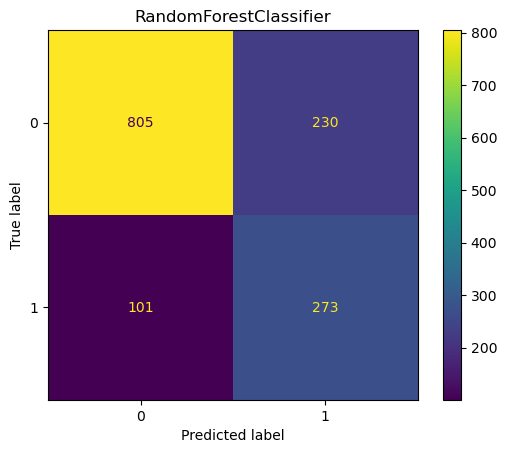

{'0': {'precision': 0.8885209713024282, 'recall': 0.7777777777777778, 'f1-score': 0.8294693456980937, 'support': 1035.0}, '1': {'precision': 0.5427435387673957, 'recall': 0.7299465240641712, 'f1-score': 0.6225769669327252, 'support': 374.0}, 'accuracy': 0.7650816181689141, 'macro avg': {'precision': 0.7156322550349119, 'recall': 0.7538621509209744, 'f1-score': 0.7260231563154095, 'support': 1409.0}, 'weighted avg': {'precision': 0.7967390268254216, 'recall': 0.7650816181689141, 'f1-score': 0.7745525609867753, 'support': 1409.0}}


In [5]:
best_model, report = random_forest.model_tuning(X_train, X_test, y_train, y_test)

print(report)

Tuning improves performance across all metrics — F1 rises from 0.593 → 0.623, with both precision (0.504 → 0.543) and recall (0.719 → 0.730) improving together, which is a more balanced gain than seen in the without-FE section.

The best configuration uses max_depth=30 with bootstrap=True, allowing deeper trees while still being regularised by min_samples_leaf=4. Compared to the tuned model without feature engineering (F1 = 0.630, recall = 0.778), the with-FE tuned model scores similarly in F1 (0.623) but with a notably higher baseline recall — suggesting the engineered features make the model easier to optimise from the start.

| Metric | Baseline | Tuned | Change |
|---|---|---|---|
| Precision (class 1) | 0.504 |	0.543 | ↑ |
| Recall (class 1) | 0.719 | 0.730 | ↑ |
| F1 (class 1) | 0.593 | **0.623** | ↑ |
| Accuracy | 0.737 | 0.765 | ↑ |

## XGBoost

## Support Vector Machine